### Step 1: Import packages

In [99]:
import os
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [3]:
os.getcwd()

'/Users/markruperto/PyCharmMiscProject'

### Step 2: Setup working directory

In [4]:
os.chdir('/Users/markruperto/Desktop/School/GCU/BIT-446/Topic 2')

In [5]:
os.getcwd()

'/Users/markruperto/Desktop/School/GCU/BIT-446/Topic 2'

### Step 3: Import data

In [6]:
pollution2 = pd.read_excel('pollution-2.xlsx')

### Step 4: Provide header information including data types

In [7]:
pollution2.info()
pollution2.head(10)

<class 'pandas.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Record       214 non-null    int64  
 1   Temperature  214 non-null    int64  
 2   Wind         214 non-null    float64
 3   CO           214 non-null    float64
 4   Month        214 non-null    int64  
 5   Day          214 non-null    int64  
dtypes: float64(2), int64(4)
memory usage: 10.2 KB


,Record,Temperature,Wind,CO,Month,Day
0,1,76,8.87,10.72,4,1
1,2,65,4.16,11.56,4,2
2,3,67,11.17,10.79,4,3
3,4,72,12.77,11.74,4,4
4,5,66,8.81,10.82,4,5
5,6,69,3.33,10.89,4,6
6,7,61,4.23,10.50,4,7
7,8,67,6.85,11.15,4,8
8,9,77,8.00,9.35,4,9
9,10,56,1.75,10.66,4,10


### Step 5: Configure the dataframe to include only the cluster analysis input fields.

In [78]:
pollution2 = pollution2[['Temperature', 'Wind', 'CO']]
print(pollution2)

     Temperature   Wind     CO
0             76   8.87  10.72
1             65   4.16  11.56
2             67  11.17  10.79
3             72  12.77  11.74
4             66   8.81  10.82
..           ...    ...    ...
209           52  23.30   6.32
210           57  18.56   5.21
211           55  17.20   7.34
212           48  16.69   4.63
213           52  19.80   5.54

[214 rows x 3 columns]


In [9]:
pollution2

,Temperature,Wind,CO
0,76,8.87,10.72
1,65,4.16,11.56
2,67,11.17,10.79
3,72,12.77,11.74
4,66,8.81,10.82
...,...,...,...
209,52,23.30,6.32
210,57,18.56,5.21
211,55,17.20,7.34
212,48,16.69,4.63


### Step 6: Normalize each record for the cluster input fields using MinMaxScaler

In [82]:
scaler = MinMaxScaler()
pollution2[['Temperature_T', 'Wind_T', 'CO_T']] = scaler.fit_transform(pollution2[['Temperature', 'Wind', 'CO']])

### Step 7: Perform the k-means cluster analysis using "KMeans"

In [85]:
X = pollution2[['Temperature_T', 'Wind_T', 'CO_T']]

kmeans = KMeans(n_clusters=3, random_state=0, n_init='auto')
kmeans.fit(X)

pollution2['Cluster'] = kmeans.labels_

### Step 8: Use "print" statements to provide the following:

In [84]:
print("Cluster assignments for each record:")
print(kmeans.labels_)

print("\nCluster centers (centroids):")
print(kmeans.cluster_centers_)

Cluster assignments for each record:
[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]

Cluster centers (centroids):
[[0.52056632 0.23509485 0.03549457]
 [0.13489736 0.7793353  0.36058977]
 [0.35976155 0.24785254 0.84346417]]


### Step 9: Use "silhouette_score" from "sklearn.metrics," determine the overall average silhouette score for the model.

In [86]:
score = silhouette_score(X, kmeans.labels_, metric='euclidean')
print(f"Overall Average Silhouette Score: {score:.3f}")

Overall Average Silhouette Score: 0.624


### Step 10: Using "SilhouetteVisualizer" in the "yellowbrick" package, create a visualization of the silhouette values for each cluster.

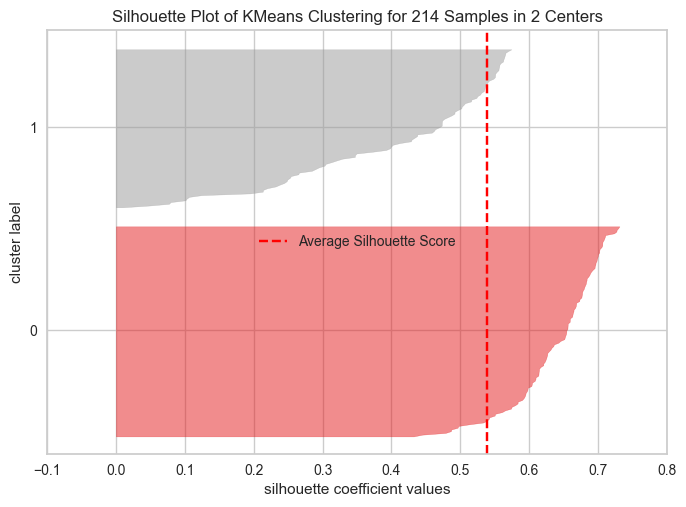

In [87]:
from yellowbrick.cluster import SilhouetteVisualizer

X = pollution2[['Temperature_T', 'Wind_T', 'CO_T']]

model = KMeans(n_clusters=2, random_state=42)

visualizer = SilhouetteVisualizer(model, force_model=True)
visualizer.fit(X)
visualizer.show()
plt.show()

### Step 11: Experiment with additional values of "k" using k-means cluster analysis

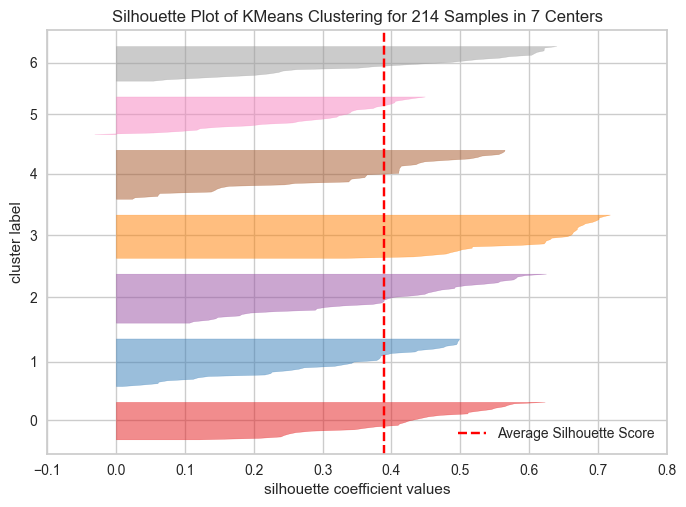

In [88]:
from yellowbrick.cluster import SilhouetteVisualizer

X = pollution2[['Temperature_T', 'Wind_T', 'CO_T']]

model = KMeans(n_clusters=7, random_state=42)

visualizer = SilhouetteVisualizer(model, force_model=True)
visualizer.fit(X)
visualizer.show()
plt.show()

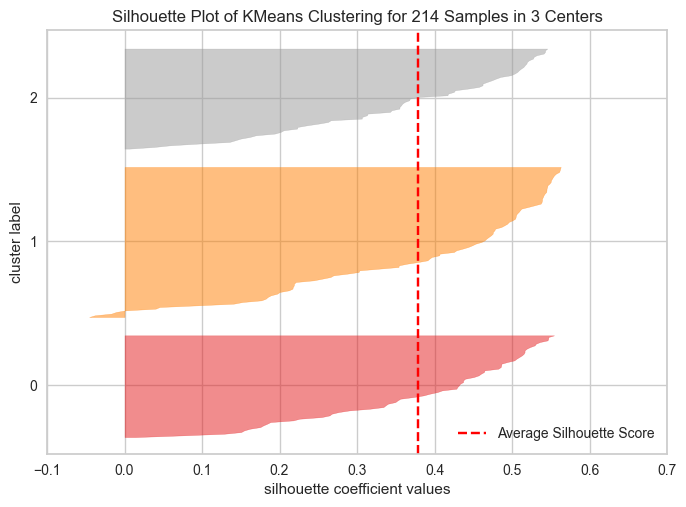

In [89]:
from yellowbrick.cluster import SilhouetteVisualizer

X = pollution2[['Temperature_T', 'Wind_T', 'CO_T']]

model = KMeans(n_clusters=3, random_state=42)

visualizer = SilhouetteVisualizer(model, force_model=True)
visualizer.fit(X)
visualizer.show()
plt.show()

### Step 12: Add Cluster assignments value for each record in the original "pollution2" dataframe.

In [76]:
print(pollution2)

     Temperature   Wind     CO  Temperature_T    Wind_T      CO_T  Cluster
0             76   8.87  10.72       0.509091  0.302921  0.818913        1
1             65   4.16  11.56       0.309091  0.133069  0.883096        1
2             67  11.17  10.79       0.345455  0.385864  0.824262        1
3             72  12.77  11.74       0.436364  0.443563  0.896849        1
4             66   8.81  10.82       0.327273  0.300757  0.826554        1
..           ...    ...    ...            ...       ...       ...      ...
209           52  23.30   6.32       0.072727  0.823296  0.482719        1
210           57  18.56   5.21       0.163636  0.652362  0.397906        1
211           55  17.20   7.34       0.127273  0.603318  0.560655        1
212           48  16.69   4.63       0.000000  0.584926  0.353590        1
213           52  19.80   5.54       0.072727  0.697079  0.423121        1

[214 rows x 7 columns]


### Step 13: Export final "pollution2" dataframe to an Excel file called: "pollution2clusters."

In [90]:
pollution2.to_excel("pollution2clusters.xlsx")

### Step 14: Create a new dataframe to summarize clusters by means for each cluster input field

In [98]:
df = pollution2.copy()
df = df.drop(columns=[col for col in df.columns
                      if col not in ['Temperature', 'Wind', 'CO', 'Cluster']])

cluster_summary = df.groupby('Cluster').mean()
print(cluster_summary.round(3))

         Temperature    Wind      CO
Cluster                             
0             76.631   6.989   0.467
1             55.419  22.081   4.722
2             67.787   7.343  11.041


### Step 15: Summarize the result cluster segments

Cluster 0 represents conditions with relatively clean air. This group has the
highest average temperature (76.6), moderate wind speed (6.99), and very low
CO levels (0.467). The low carbon monoxide level suggests minimal pollution.
Moderate wind may help move pollutants away, preventing them from building up
in the air. Because this cluster has the lowest CO level of all groups, it
likely represents normal or good air-quality conditions.

Cluster 1 represents cooler and very windy conditions. It has the lowest
temperature (55.4) and the highest wind speed (22.08). CO levels (4.722) are
higher than Cluster 0 but lower than Cluster 2. The strong wind likely helps
spread pollutants out, which keeps CO levels from becoming extremely high.
This cluster may represent days when wind helps reduce pollution buildup.

Cluster 2 shows the highest pollution levels in the dataset. Temperatures are
moderate (67.8) and wind speed is fairly low (7.34), but CO levels are very
high (11.041). Lower wind speeds may allow pollution to stay concentrated in
the air. This cluster likely represents conditions where pollution builds up
because there is not enough wind to move it away.

### Step 16: Summarize your overall conclusions

The clustering analysis grouped the air quality data into three different groups based on temperature, wind speed, and carbon monoxide (CO) levels. Each cluster shows a different type of weather and pollution condition.

Cluster 0 represents cleaner air conditions. This group has the highest temperature (76.6), moderate wind speeds (6.99), and very low CO levels (0.467). The low CO level suggests there is very little pollution in the air. The moderate wind likely helps move pollutants away so they do not build up.

Cluster 1 represents cooler but very windy conditions. This cluster has the lowest temperature (55.4) and the highest wind speed (22.08). The CO level (4.722) is higher than Cluster 0 but still much lower than Cluster 2. The strong wind likely spreads pollution out, which keeps the concentration from getting too high.

Cluster 2 represents the highest pollution levels in the dataset. The temperature is moderate (67.8) and the wind speed is fairly low (7.34), but the CO level is very high (11.041). Because the wind is lower, pollution may stay in one place and build up in the air.

Overall, the results show that wind speed may play an important role in air pollution levels. Higher wind speeds help spread pollutants out, while lower wind speeds may allow pollution to build up.

The data collection and clustering analysis help turn raw environmental data into useful insights. A manager could use this information to better understand when pollution is more likely to increase. This could help with planning air quality monitoring, environmental policies, or pollution control efforts.